# 📉 Chương 4: Phân Tích Tự Tương Quan (ACF & PACF)
## Advanced Data Science - Session 5

---

**Mục tiêu chương này:**
- Hiểu Autocorrelation (ACF) và Partial Autocorrelation (PACF)
- Biết cách đọc và diễn giải ACF/PACF plots
- Sử dụng ACF/PACF để xác định tham số cho ARIMA model
- Thực hành nhận biết AR, MA, ARMA từ ACF/PACF

## 4.1 Autocorrelation (ACF) Là Gì?

### 🎯 Ví dụ minh họa:

Tưởng tượng bạn đo **nhiệt độ Hà Nội mỗi ngày**:
- Nếu hôm nay **35°C**, thì ngày mai có thể cũng **34-36°C** → Tương quan **cao** (lag 1)
- Nếu hôm nay **35°C**, thì 1 tuần sau có thể **30-37°C** → Tương quan **vừa** (lag 7)
- Nếu hôm nay **35°C**, thì 6 tháng sau có thể **15°C** (mùa đông) → Tương quan **thấp/âm** (lag 180)

→ **ACF** đo lường mức độ tương quan này ở mỗi **lag**.

### 📐 Công thức:

```
ACF(k) = Corr(Y_t, Y_{t-k}) = Cov(Y_t, Y_{t-k}) / Var(Y_t)
```

- **k = 0:** ACF = 1 (tương quan với chính nó)
- **k = 1:** Tương quan với quan sát trước 1 bước
- **k = 2:** Tương quan với quan sát trước 2 bước

### 🔑 Đặc điểm quan trọng:
- ACF bao gồm cả **trực tiếp** và **gián tiếp** correlation
- Ví dụ: ACF(2) bao gồm cả ảnh hưởng qua lag 1 → lag 2

## 4.2 Partial Autocorrelation (PACF) Là Gì?

### 🎯 Ví dụ minh họa:

Trong một gia đình 3 thế hệ:
- Ông → Bố → Con
- **ACF:** Con giống Ông? → Có (nhưng qua Bố!)
- **PACF:** Con giống Ông **trực tiếp** (bỏ qua ảnh hưởng của Bố)? → Có thể ít hơn

**PACF loại bỏ ảnh hưởng gián tiếp**, chỉ giữ tương quan trực tiếp.

### 📐 Ý nghĩa:

- **PACF(1):** = ACF(1) (không có gì để loại)
- **PACF(2):** Tương quan Y(t) với Y(t-2), **sau khi loại bỏ** ảnh hưởng của Y(t-1)
- **PACF(3):** Tương quan Y(t) với Y(t-3), **sau khi loại bỏ** ảnh hưởng của Y(t-1) và Y(t-2)

## 4.3 Sử Dụng ACF/PACF Để Xác Định Model

---

### 🧩 Bước 0: Hiểu Các Model Trước (nếu bạn chưa biết gì)

Trước khi dùng ACF/PACF, bạn cần biết mình đang chọn model **nào**. Có 3 loại cơ bản:

---

#### 📦 Model 1: AR (AutoRegressive) — "Tự hồi quy"

> **Ý tưởng:** Giá trị **hôm nay** phụ thuộc vào giá trị **những ngày trước**.

**Ví dụ đời thực:** Giá vàng hôm nay
- Giá vàng hôm nay = 70% × (giá hôm qua) + một ít may rủi
- → Hôm qua cao → Hôm nay cũng cao. Hôm qua thấp → Hôm nay cũng thấp.

**Công thức AR(1):**
```
Y(t) = φ₁ × Y(t-1) + ε(t)
        ↑ giá hôm qua  ↑ sai số ngẫu nhiên
```

**AR(2):** Phụ thuộc **2 ngày** trước
```
Y(t) = φ₁ × Y(t-1) + φ₂ × Y(t-2) + ε(t)
```

**AR(p):** Phụ thuộc **p ngày** trước — `p` gọi là **order (bậc)** của model.

---

#### 📦 Model 2: MA (Moving Average) — "Trung bình trượt của sai số"

> **Ý tưởng:** Giá trị **hôm nay** phụ thuộc vào **sai số (shock)** của những ngày trước — **không phải** giá trị cũ!

**Ví dụ đời thực:** Đánh giá nhà hàng trên Google Maps
- Một ngày có đoàn khách khó tính → reviews xấu bất thường (shock âm)
- Review hôm nay = đánh giá thực + ảnh hưởng từ "cơn bão reviews" hôm qua
- Sau 1-2 ngày thì hết ảnh hưởng, như thể chưa có chuyện gì

**Công thức MA(1):**
```
Y(t) = ε(t) + θ₁ × ε(t-1)
        ↑ shock hôm nay  ↑ ảnh hưởng còn sót từ shock hôm qua
```

**MA(q):** Ảnh hưởng của shock kéo dài **q bước** — `q` gọi là **order** của model.

---

#### 📦 Model 3: ARMA(p, q) — Kết hợp cả hai

> **Ý tưởng:** Giá trị hôm nay phụ thuộc vào **CẢ** giá trị cũ (AR) **VÀ** sai số cũ (MA).

```
Y(t) = φ₁ × Y(t-1) + ... + ε(t) + θ₁ × ε(t-1) + ...
        ────── phần AR ──────          ───── phần MA ─────
```

---

#### 📦 Model 4: ARIMA(p, d, q) — AR + Differencing + MA

Thêm tham số `d` để xử lý dữ liệu **không dừng** (non-stationary, có xu hướng tăng/giảm):
- **d = 0:** Dữ liệu đã dừng, không cần làm gì
- **d = 1:** Lấy sai phân 1 lần (Y(t) - Y(t-1)) để làm dừng
- **d = 2:** Lấy sai phân 2 lần (hiếm gặp)

---

### 🔑 Bước 1: Dùng ACF/PACF Để Nhận Biết Model

Bây giờ bạn đã biết AR, MA, ARMA là gì. Vấn đề là: **nhìn vào dữ liệu thực, làm sao biết dùng cái nào?**

→ Câu trả lời: **Vẽ ACF và PACF, rồi quan sát pattern!**

---

#### 🔍 Pattern 1: AR(p) → PACF "cắt ngang", ACF "giảm dần"

```
ACF:   ████████████░░░░░░░░░░░░░░  (dài, giảm dần từ từ)
PACF:  █████░░░░░░░░░░░░░░░░░░░░░  (chỉ có vài thanh đầu, rồi CẮT ngay)
             ↑ cắt ở đây → p = 2
```

**Tại sao PACF cắt còn ACF giảm dần?**
- AR(2): Y(t) phụ thuộc **trực tiếp** Y(t-1) và Y(t-2)
- PACF đo tương quan **trực tiếp** → chỉ lag 1 và lag 2 có ý nghĩa → PACF cắt sau lag 2
- ACF đo **tổng tương quan** → Y(t) tương quan Y(t-3) vì qua chuỗi t-1 → t-2 → t-3 → ACF giảm dần

---

#### 🔍 Pattern 2: MA(q) → ACF "cắt ngang", PACF "giảm dần"

```
ACF:   ████░░░░░░░░░░░░░░░░░░░░░░  (chỉ vài thanh đầu, rồi CẮT ngay)
PACF:  ████████████░░░░░░░░░░░░░░  (dài, giảm dần từ từ)
            ↑ cắt ở đây → q = 2
```

**Tại sao ACF cắt còn PACF giảm dần?**
- MA(2): Y(t) chịu ảnh hưởng shock trong **đúng 2 bước**, sau đó hết
- ACF lag 3 trở đi = 0 vì không còn shock nào kéo dài đến đó → ACF cắt sau lag 2
- PACF thì giảm dần vì MA tạo ra tương quan "ngược" lan qua nhiều lag

---

#### 🔍 Pattern 3: ARMA(p,q) → Cả hai đều "giảm dần"

```
ACF:   ██████████████░░░░░░░░░░░░  (giảm dần)
PACF:  ██████████████░░░░░░░░░░░░  (giảm dần)
```

→ Không thấy chỗ "cắt" rõ ràng = có cả AR lẫn MA → Dùng ARMA hoặc auto_arima để tìm p, q

---

### 📊 Bảng Quy Tắc Vàng (Cần Thuộc!)

| ACF | PACF | → Model | Bạn cần tìm |
|-----|------|---------|-------------|
| Giảm dần (decay) | **Cắt** sau lag **p** | → **AR(p)** | Đếm thanh PACF ngoài vùng xanh → đó là **p** |
| **Cắt** sau lag **q** | Giảm dần (decay) | → **MA(q)** | Đếm thanh ACF ngoài vùng xanh → đó là **q** |
| Giảm dần | Giảm dần | → **ARMA(p,q)** | Dùng auto_arima để chọn tự động |

---

### 🎯 Cách Đọc Biểu Đồ ACF/PACF Thực Tế

```python
plot_acf(data, lags=40)   # Vẽ ACF
plot_pacf(data, lags=40)  # Vẽ PACF
```

**Vùng màu xanh (confidence interval)** là ranh giới:
- Thanh **nằm trong** vùng xanh → **Không có ý nghĩa** (bỏ qua)
- Thanh **vượt ra ngoài** vùng xanh → **Có ý nghĩa** (đếm cái này!)

**Cách đếm:**
1. Nhìn **PACF**: Đếm bao nhiêu thanh liên tiếp (từ lag 1) vượt ra ngoài vùng xanh trước khi "cắt" → Đó là **p**
2. Nhìn **ACF**: Đếm bao nhiêu thanh liên tiếp (từ lag 1) vượt ra ngoài vùng xanh trước khi "cắt" → Đó là **q**
3. Nếu cả hai "giảm dần" không "cắt" → Dùng `auto_arima`

---

### 💡 Mẹo Nhớ Nhanh

> **"PACF → p, ACF → q"**
> - **P**ACF → **p** (AR order)  
> - A**C**F → **q** (MA order, vì MA viết tắt từ Moving **A**verage, q đi với A)

Hoặc nhớ theo ví dụ:
- **AR:** như quán cà phê — khách hôm nay phụ thuộc khách hôm qua (momentum, xu hướng)
- **MA:** như thời tiết xấu đột ngột — ảnh hưởng của cơn mưa hôm qua còn sót lại hôm nay, rồi hết

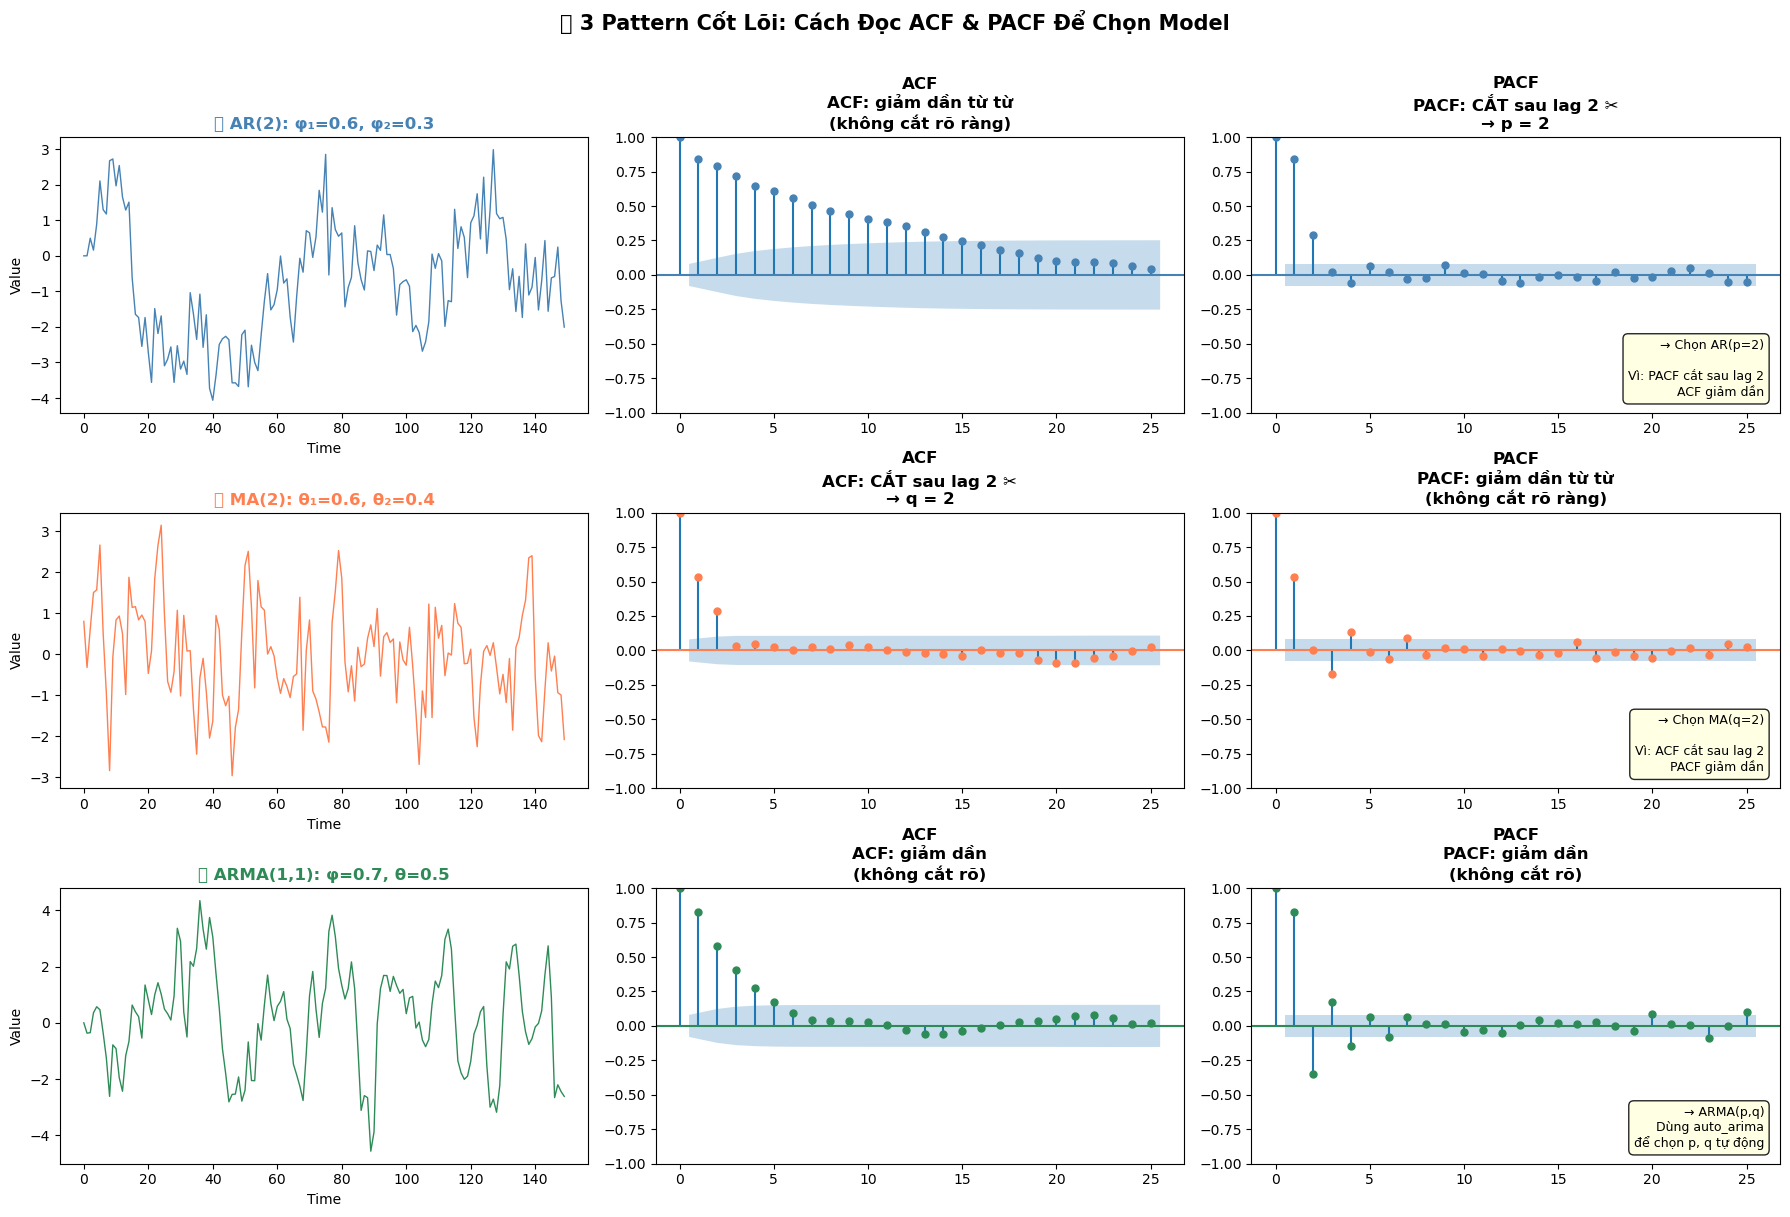


╔══════════════════════════════════════════════════════════════╗
║          BẢNG TÓM TẮT: CÁCH ĐỌC ACF & PACF                  ║
╠══════════════════════════════════════════════════════════════╣
║  Quan sát               │  Kết luận                          ║
║─────────────────────────┼────────────────────────────────────║
║  PACF cắt sau lag p     │ → Dùng AR(p)   — p là bậc AR      ║
║  ACF  cắt sau lag q     │ → Dùng MA(q)   — q là bậc MA      ║
║  Cả 2 giảm dần (decay)  │ → Dùng ARMA    — dùng auto_arima  ║
╚══════════════════════════════════════════════════════════════╝

💡 Mẹo nhớ: PACF → p (AR),  ACF → q (MA)



In [2]:

# ============================================================
# MINH HỌA TRỰC QUAN: 3 Pattern ACF/PACF → 3 Model Khác Nhau
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 600

# ----- Tạo 3 loại process -----

# 1. AR(2): Y(t) = 0.6*Y(t-1) + 0.3*Y(t-2) + noise
ar2 = [0, 0]
#Khởi tạo 2 giá trị đầu tiên vì AR(2) cần 2 giá trị trước đó để tính toán
for i in range(2, n):
    # range(2, n) vì chúng ta đã khởi tạo 2 giá trị đầu tiên
    #range(2, n) sẽ tạo ra các chỉ số từ 2 đến n-1, đảm bảo rằng chúng ta có đủ dữ liệu để tính toán AR(2) mà không bị lỗi index out of range
    # Công thức AR(2) với noise là nhiễu ngẫu nhiên từ phân phối chuẩn
    ar2.append(0.6 * ar2[-1] + 0.3 * ar2[-2] + np.random.normal(0, 1))
ar2 = np.array(ar2)

# 2. MA(2): Y(t) = noise(t) + 0.6*noise(t-1) + 0.4*noise(t-2)
eps = np.random.normal(0, 1, n+2)
ma2 = np.array([eps[i] + 0.6*eps[i-1] + 0.4*eps[i-2] for i in range(2, n+2)])

# 3. ARMA(1,1): Y(t) = 0.7*Y(t-1) + noise(t) + 0.5*noise(t-1)
arma = [0]
eps2 = np.random.normal(0, 1, n+1)
for i in range(1, n):
    arma.append(0.7 * arma[-1] + eps2[i] + 0.5 * eps2[i-1])
arma = np.array(arma)

# ----- Vẽ 3x3 grid -----
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('📊 3 Pattern Cốt Lõi: Cách Đọc ACF & PACF Để Chọn Model', 
             fontsize=15, fontweight='bold', y=1.01)

DATA = [
    (ar2,  'AR(2): φ₁=0.6, φ₂=0.3', 'steelblue',
     'ACF: giảm dần từ từ\n(không cắt rõ ràng)',
     'PACF: CẮT sau lag 2 ✂️\n→ p = 2',
     '→ Chọn AR(p=2)\n\nVì: PACF cắt sau lag 2\n    ACF giảm dần'),

    (ma2,  'MA(2): θ₁=0.6, θ₂=0.4',  'coral',
     'ACF: CẮT sau lag 2 ✂️\n→ q = 2',
     'PACF: giảm dần từ từ\n(không cắt rõ ràng)',
     '→ Chọn MA(q=2)\n\nVì: ACF cắt sau lag 2\n    PACF giảm dần'),

    (arma, 'ARMA(1,1): φ=0.7, θ=0.5', 'seagreen',
     'ACF: giảm dần\n(không cắt rõ)',
     'PACF: giảm dần\n(không cắt rõ)',
     '→ ARMA(p,q)\nDùng auto_arima\nđể chọn p, q tự động'),
]

for row, (data, title, color, acf_note, pacf_note, conclusion) in enumerate(DATA):
    # Cột 1: Time series
    axes[row, 0].plot(data[:150], color=color, linewidth=1)
    axes[row, 0].set_title(f'📈 {title}', fontweight='bold', color=color)
    axes[row, 0].set_xlabel('Time')
    axes[row, 0].set_ylabel('Value')

    # Cột 2: ACF
    plot_acf(data, ax=axes[row, 1], lags=25, alpha=0.05, color=color)
    axes[row, 1].set_title(f'ACF\n{acf_note}', fontweight='bold')

    # Cột 3: PACF
    plot_pacf(data, ax=axes[row, 2], lags=25, alpha=0.05, color=color)
    axes[row, 2].set_title(f'PACF\n{pacf_note}', fontweight='bold')

    # Thêm chú thích kết luận vào góc biểu đồ PACF
    axes[row, 2].text(0.97, 0.05, conclusion,
                      transform=axes[row, 2].transAxes,
                      fontsize=9, verticalalignment='bottom',
                      horizontalalignment='right',
                      bbox=dict(boxstyle='round,pad=0.4',
                                facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

print("""
╔══════════════════════════════════════════════════════════════╗
║          BẢNG TÓM TẮT: CÁCH ĐỌC ACF & PACF                  ║
╠══════════════════════════════════════════════════════════════╣
║  Quan sát               │  Kết luận                          ║
║─────────────────────────┼────────────────────────────────────║
║  PACF cắt sau lag p     │ → Dùng AR(p)   — p là bậc AR      ║
║  ACF  cắt sau lag q     │ → Dùng MA(q)   — q là bậc MA      ║
║  Cả 2 giảm dần (decay)  │ → Dùng ARMA    — dùng auto_arima  ║
╚══════════════════════════════════════════════════════════════╝

💡 Mẹo nhớ: PACF → p (AR),  ACF → q (MA)
""")


---
## 🔬 Phần Thực Hành
---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Import thành công!')

✅ Import thành công!


### 📝 Ví dụ 1: ACF của Các Loại Process Khác Nhau

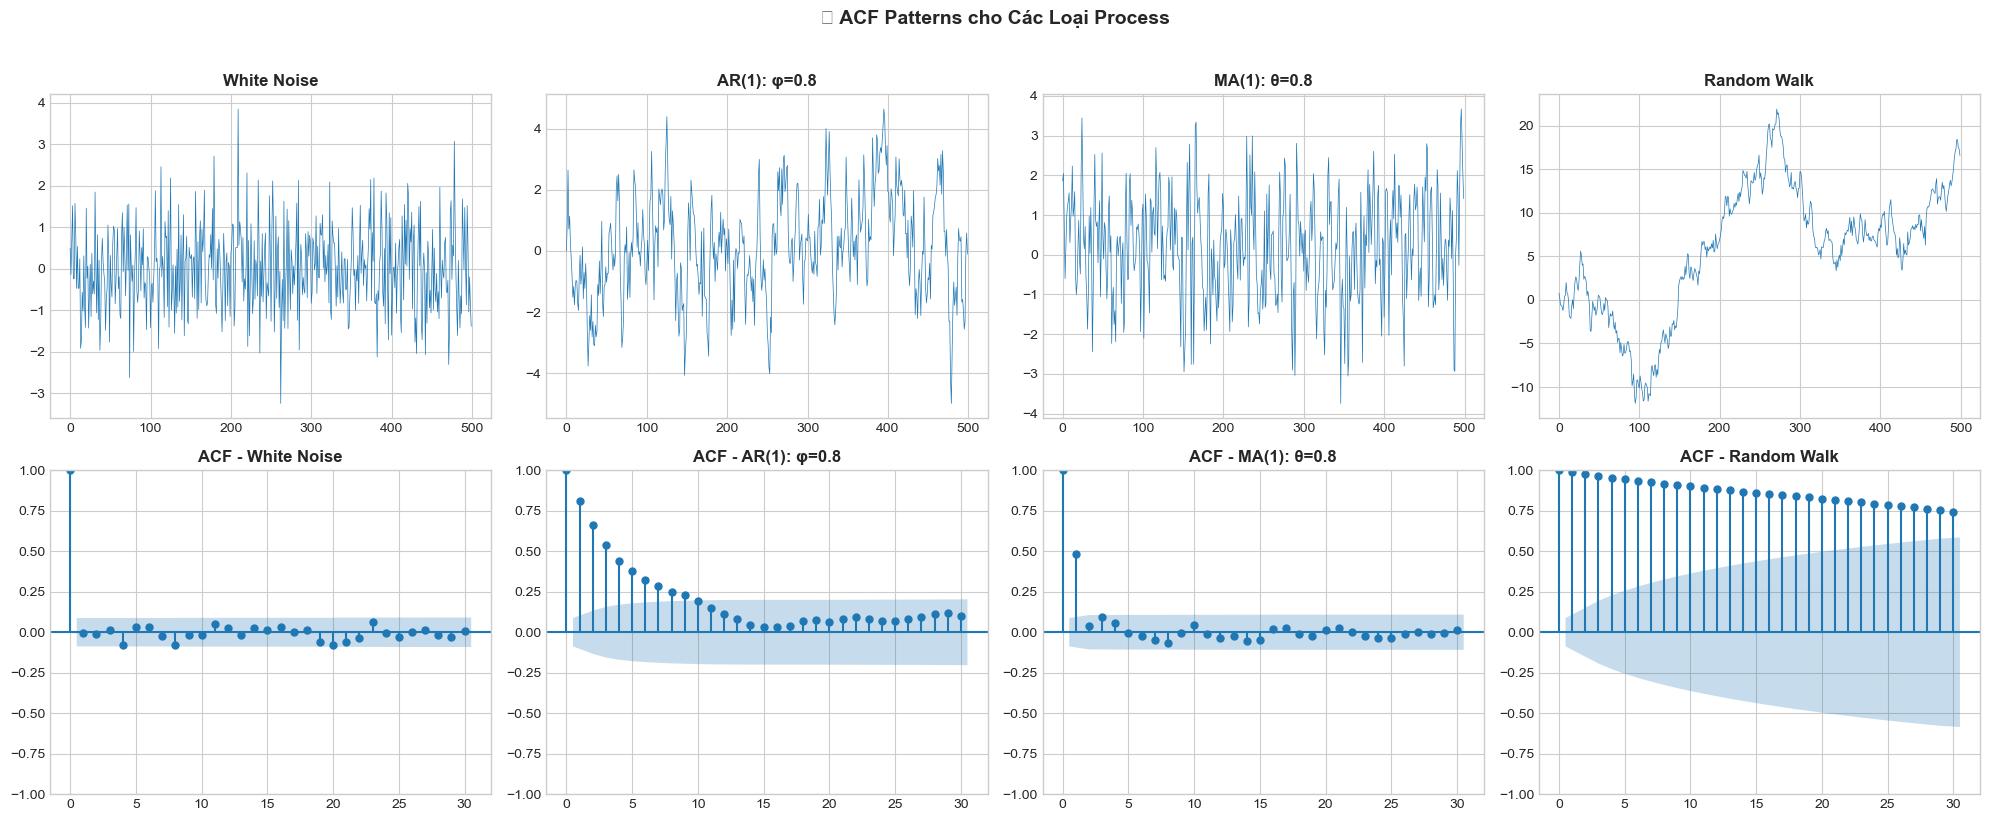

🔍 Nhận xét:
  White Noise: ACF ≈ 0 ở mọi lag → Không có tương quan
  AR(1):       ACF giảm dần (exponential decay)
  MA(1):       ACF cắt ngang sau lag 1 → q=1
  Random Walk: ACF giảm rất chậm → NON-STATIONARY!


In [4]:
np.random.seed(42)
n = 500

# 1. White Noise (không có tương quan)
white_noise = np.random.normal(0, 1, n)

# 2. AR(1) process: Y(t) = 0.8 * Y(t-1) + error
ar1 = [0]
for i in range(1, n):
    ar1.append(0.8 * ar1[i-1] + np.random.normal(0, 1))
ar1 = np.array(ar1)

# 3. MA(1) process: Y(t) = error(t) + 0.8 * error(t-1)
errors = np.random.normal(0, 1, n+1)
ma1 = np.array([errors[i] + 0.8 * errors[i-1] for i in range(1, n+1)])

# 4. Random Walk (non-stationary)
random_walk = np.cumsum(np.random.normal(0, 1, n))

# Plot ACF cho từng loại
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

data_dict = {
    'White Noise': white_noise,
    'AR(1): φ=0.8': ar1,
    'MA(1): θ=0.8': ma1,
    'Random Walk': random_walk
}

for idx, (name, data) in enumerate(data_dict.items()):
    # Time series plot
    axes[0, idx].plot(data, linewidth=0.5)
    axes[0, idx].set_title(name, fontweight='bold')
    
    # ACF plot
    plot_acf(data, ax=axes[1, idx], lags=30, alpha=0.05)
    axes[1, idx].set_title(f'ACF - {name}', fontweight='bold')

plt.suptitle('📊 ACF Patterns cho Các Loại Process', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('🔍 Nhận xét:')
print('  White Noise: ACF ≈ 0 ở mọi lag → Không có tương quan')
print('  AR(1):       ACF giảm dần (exponential decay)')
print('  MA(1):       ACF cắt ngang sau lag 1 → q=1')
print('  Random Walk: ACF giảm rất chậm → NON-STATIONARY!')

### 📝 Ví dụ 2: PACF và Cách Đọc

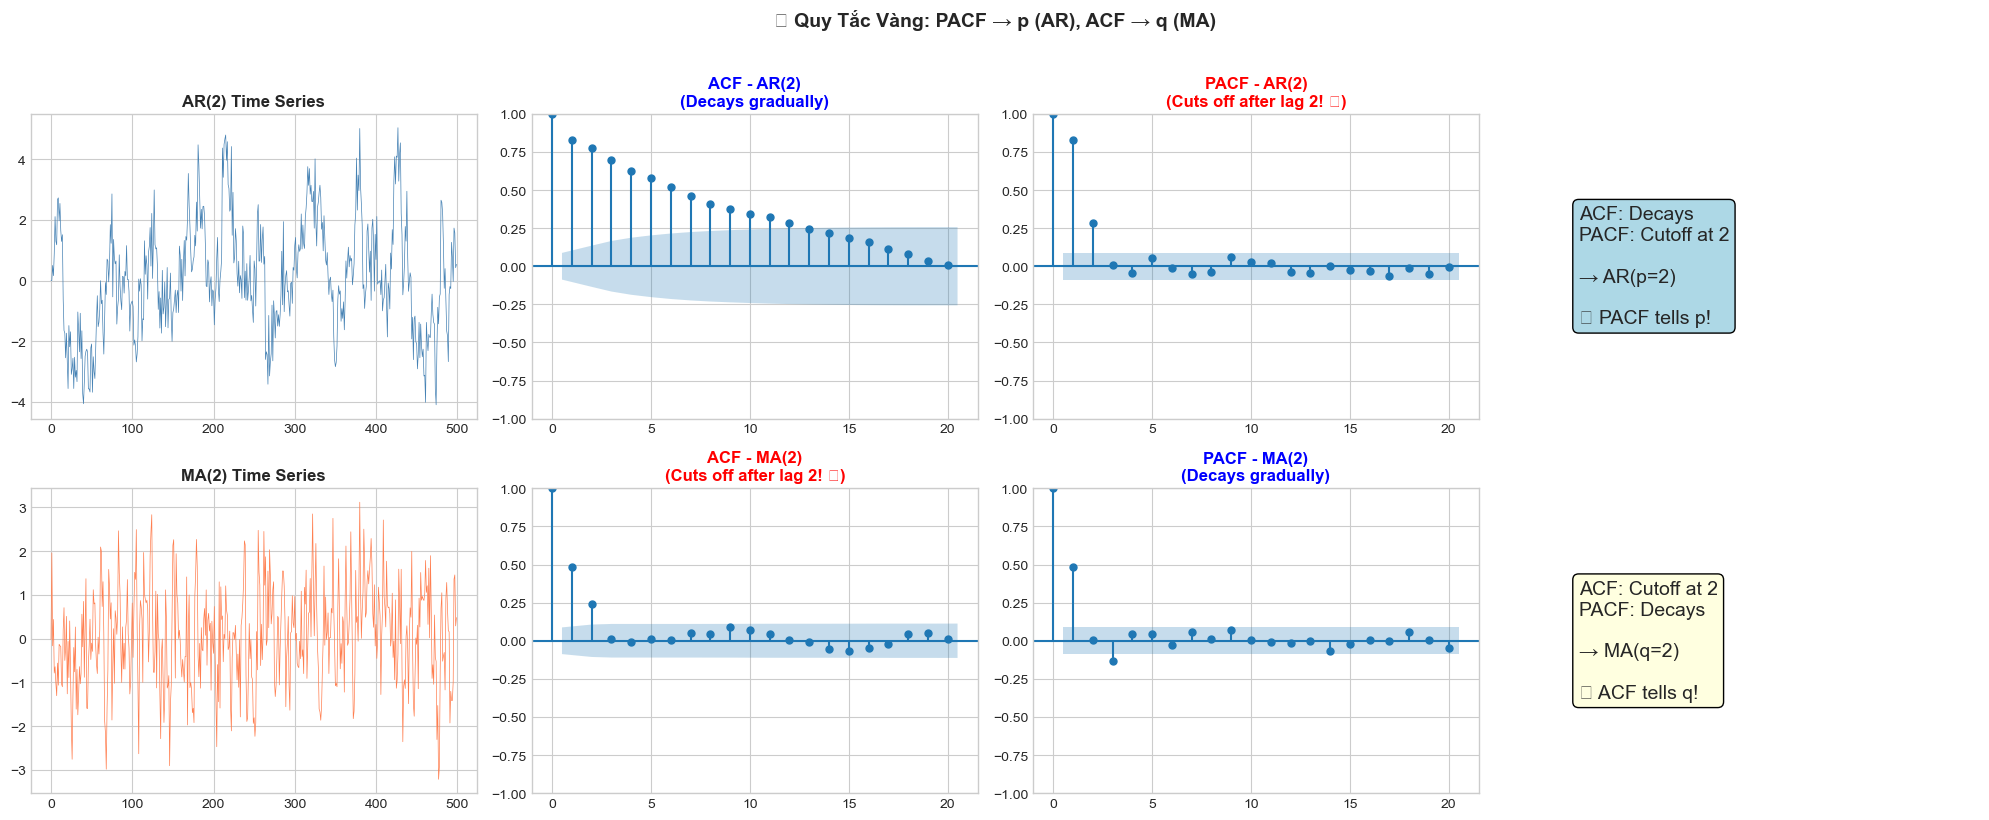

In [5]:
# Tạo AR(2): Y(t) = 0.6*Y(t-1) + 0.3*Y(t-2) + error
np.random.seed(42)
n = 500

ar2 = [0, 0]
for i in range(2, n):
    ar2.append(0.6 * ar2[i-1] + 0.3 * ar2[i-2] + np.random.normal(0, 1))
ar2 = np.array(ar2)

# Tạo MA(2): Y(t) = error + 0.5*error(t-1) + 0.3*error(t-2)
errors = np.random.normal(0, 1, n+2)
ma2 = np.array([errors[i] + 0.5*errors[i-1] + 0.3*errors[i-2] for i in range(2, n+2)])

# Plot ACF + PACF side by side
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# AR(2)
axes[0, 0].plot(ar2, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('AR(2) Time Series', fontweight='bold')
plot_acf(ar2, ax=axes[0, 1], lags=20)
axes[0, 1].set_title('ACF - AR(2)\n(Decays gradually)', fontweight='bold', color='blue')
plot_pacf(ar2, ax=axes[0, 2], lags=20)
axes[0, 2].set_title('PACF - AR(2)\n(Cuts off after lag 2! ✅)', fontweight='bold', color='red')
axes[0, 3].text(0.1, 0.5, 'ACF: Decays\nPACF: Cutoff at 2\n\n→ AR(p=2)\n\n📌 PACF tells p!', 
                fontsize=14, verticalalignment='center', 
                bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[0, 3].axis('off')

# MA(2)
axes[1, 0].plot(ma2, linewidth=0.5, color='coral')
axes[1, 0].set_title('MA(2) Time Series', fontweight='bold')
plot_acf(ma2, ax=axes[1, 1], lags=20)
axes[1, 1].set_title('ACF - MA(2)\n(Cuts off after lag 2! ✅)', fontweight='bold', color='red')
plot_pacf(ma2, ax=axes[1, 2], lags=20)
axes[1, 2].set_title('PACF - MA(2)\n(Decays gradually)', fontweight='bold', color='blue')
axes[1, 3].text(0.1, 0.5, 'ACF: Cutoff at 2\nPACF: Decays\n\n→ MA(q=2)\n\n📌 ACF tells q!', 
                fontsize=14, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[1, 3].axis('off')

plt.suptitle('🔑 Quy Tắc Vàng: PACF → p (AR), ACF → q (MA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Ví dụ 3: Nhận Diện Seasonality Từ ACF

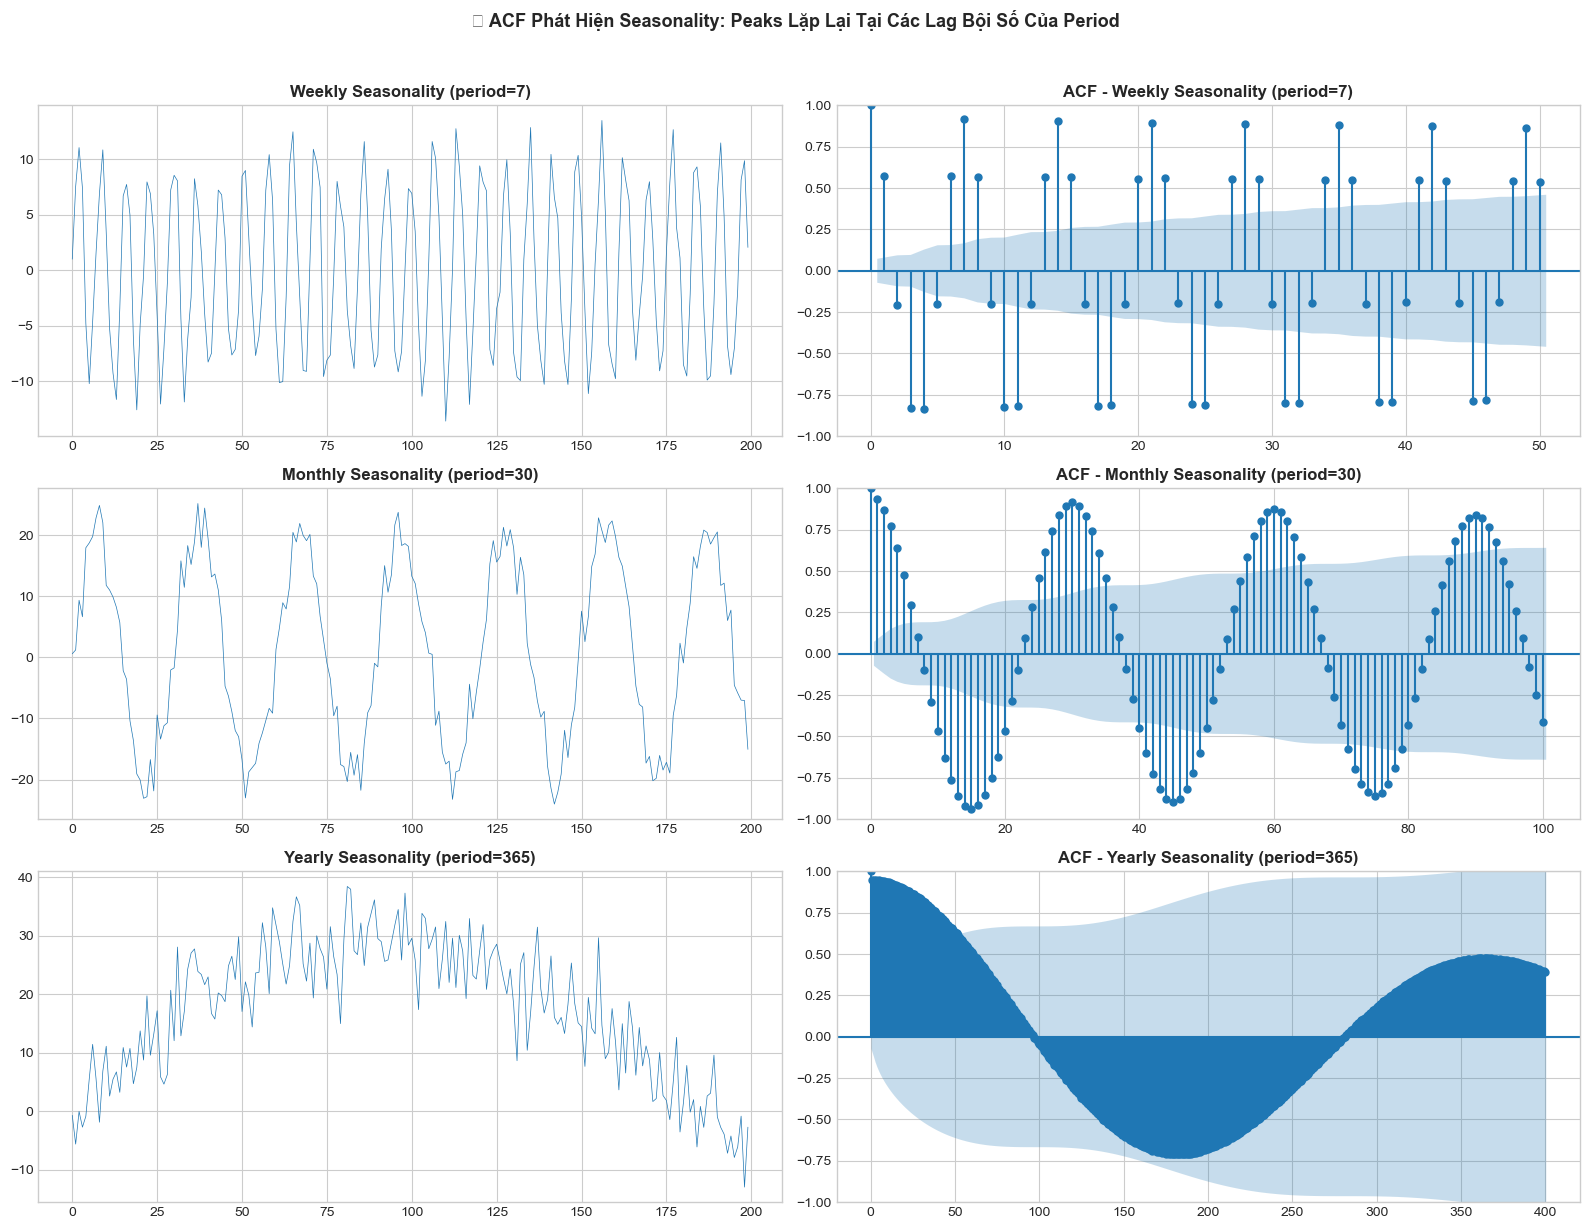

💡 ACF giúp phát hiện seasonality:
   Weekly:  Peaks tại lag 7, 14, 21, 28...
   Monthly: Peaks tại lag 30, 60, 90...
   Yearly:  Peaks tại lag 365, 730...


In [6]:
# Tạo dữ liệu có seasonal pattern
np.random.seed(42)
n = 365 * 2
t = np.arange(n)

# Weekly seasonality
weekly = 10 * np.sin(2 * np.pi * t / 7) + np.random.normal(0, 2, n)

# Monthly seasonality  
monthly = 20 * np.sin(2 * np.pi * t / 30) + np.random.normal(0, 3, n)

# Yearly seasonality
yearly = 30 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 5, n)

# Plot ACF to detect seasonality
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for idx, (data, name, period) in enumerate([
    (weekly, 'Weekly Seasonality (period=7)', 50),
    (monthly, 'Monthly Seasonality (period=30)', 100),
    (yearly, 'Yearly Seasonality (period=365)', 400)
]):
    axes[idx, 0].plot(data[:200], linewidth=0.5)
    axes[idx, 0].set_title(f'{name}', fontweight='bold')
    
    plot_acf(data, ax=axes[idx, 1], lags=period)
    axes[idx, 1].set_title(f'ACF - {name}', fontweight='bold')

plt.suptitle('🔍 ACF Phát Hiện Seasonality: Peaks Lặp Lại Tại Các Lag Bội Số Của Period', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 ACF giúp phát hiện seasonality:')
print('   Weekly:  Peaks tại lag 7, 14, 21, 28...')
print('   Monthly: Peaks tại lag 30, 60, 90...')
print('   Yearly:  Peaks tại lag 365, 730...')

### 📝 Ví dụ 4: Hướng Dẫn Chọn Parameters p, d, q

  PHÂN TÍCH ACF/PACF → ĐỀ XUẤT ARIMA(p,d,q)

📌 Bước 1: Xác định d (differencing order)
   d=0: ADF p-value = 0.3281 → NON-STATIONARY ❌ → Diff thêm
   d=1: ADF p-value = 0.0000 → STATIONARY ✅
   → d = 1


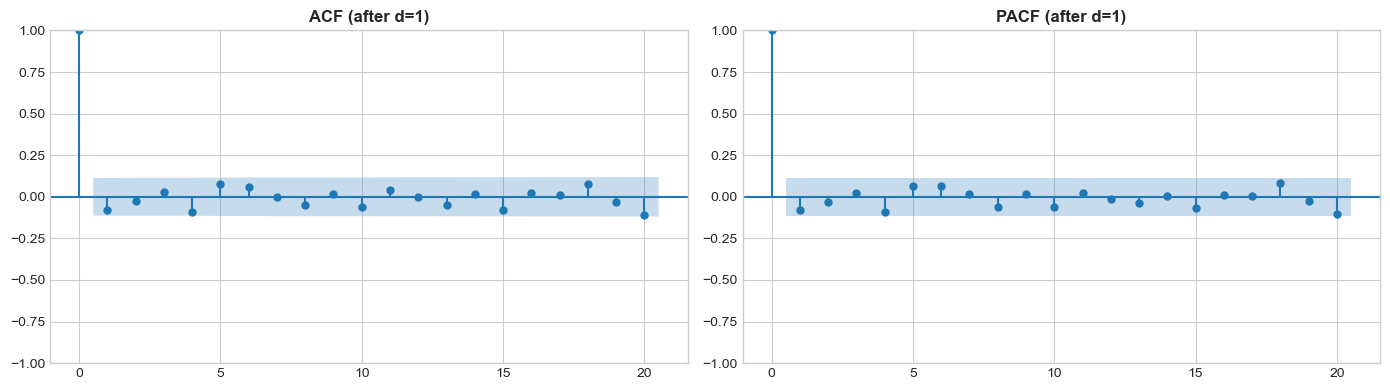


📌 Bước 2: Xác định p và q
   Nhìn PACF → p ≈ 0 (significant lags trong PACF)
   Nhìn ACF  → q ≈ 0 (significant lags trong ACF)

🎯 ĐỀ XUẤT: ARIMA(0, 1, 0)
   Hoặc thử: ARIMA(0, 1, 0) hoặc ARIMA(1, 1, 1)


In [7]:
def suggest_arima_params(series, max_lags=20):
    """
    Phân tích ACF/PACF và đề xuất tham số ARIMA(p,d,q)
    """
    from statsmodels.tsa.stattools import adfuller
    
    print('='*60)
    print('  PHÂN TÍCH ACF/PACF → ĐỀ XUẤT ARIMA(p,d,q)')
    print('='*60)
    
    # Bước 1: Xác định d
    print('\n📌 Bước 1: Xác định d (differencing order)')
    d = 0
    temp = series.copy()
    for i in range(3):
        p_val = adfuller(temp.dropna())[1]
        if p_val < 0.05:
            print(f'   d={i}: ADF p-value = {p_val:.4f} → STATIONARY ✅')
            d = i
            break
        else:
            print(f'   d={i}: ADF p-value = {p_val:.4f} → NON-STATIONARY ❌ → Diff thêm')
            temp = temp.diff().dropna()
            d = i + 1
    
    print(f'   → d = {d}')
    
    # Bước 2: Plot ACF/PACF trên data đã stationary
    stationary_data = series.copy()
    for _ in range(d):
        stationary_data = stationary_data.diff().dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(stationary_data, ax=axes[0], lags=max_lags, alpha=0.05)
    axes[0].set_title(f'ACF (after d={d})', fontweight='bold')
    plot_pacf(stationary_data, ax=axes[1], lags=max_lags, alpha=0.05)
    axes[1].set_title(f'PACF (after d={d})', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Bước 3: Xác định p và q
    acf_vals = acf(stationary_data, nlags=max_lags)
    pacf_vals = pacf(stationary_data, nlags=max_lags)
    
    # Confidence bound
    conf = 1.95 / np.sqrt(len(stationary_data))
    
    # Tìm q từ ACF (lag đầu tiên nằm trong confidence interval 95%)
    q = 0
    for i in range(1, len(acf_vals)):
        if abs(acf_vals[i]) > conf:
            q = i
        else:
            break
    
    # Tìm p từ PACF
    p = 0
    for i in range(1, len(pacf_vals)):
        if abs(pacf_vals[i]) > conf:
            p = i
        else:
            break
    
    print(f'\n📌 Bước 2: Xác định p và q')
    print(f'   Nhìn PACF → p ≈ {p} (significant lags trong PACF)')
    print(f'   Nhìn ACF  → q ≈ {q} (significant lags trong ACF)')
    print(f'\n🎯 ĐỀ XUẤT: ARIMA({p}, {d}, {q})')
    print(f'   Hoặc thử: ARIMA({max(p-1,0)}, {d}, {max(q-1,0)}) hoặc ARIMA({p+1}, {d}, {q+1})')
    
    return p, d, q

# Test
np.random.seed(42)
# Tạo ARIMA(2,1,1) process
y = np.cumsum(np.random.normal(0, 1, 300))  # Random walk
test_series = pd.Series(y)

p, d, q = suggest_arima_params(test_series)

### 📝 Ví dụ 5: ACF/PACF Trên Dữ Liệu Thực

In [ ]:
# Đọc dữ liệu thực
data_retail = pd.read_csv('../Bai thi thu/Course Files/retail_sales_dataset.csv')

# Xử lý
date_cols = [col for col in data_retail.columns if 'date' in col.lower()]
print(f'Các cột: {data_retail.columns.tolist()}')
print(f'Cột date: {date_cols}')
print(f'\n5 dòng đầu:')
data_retail.head()

Các cột số: ['sale', 'stock', 'price']

Phân tích cột: sale


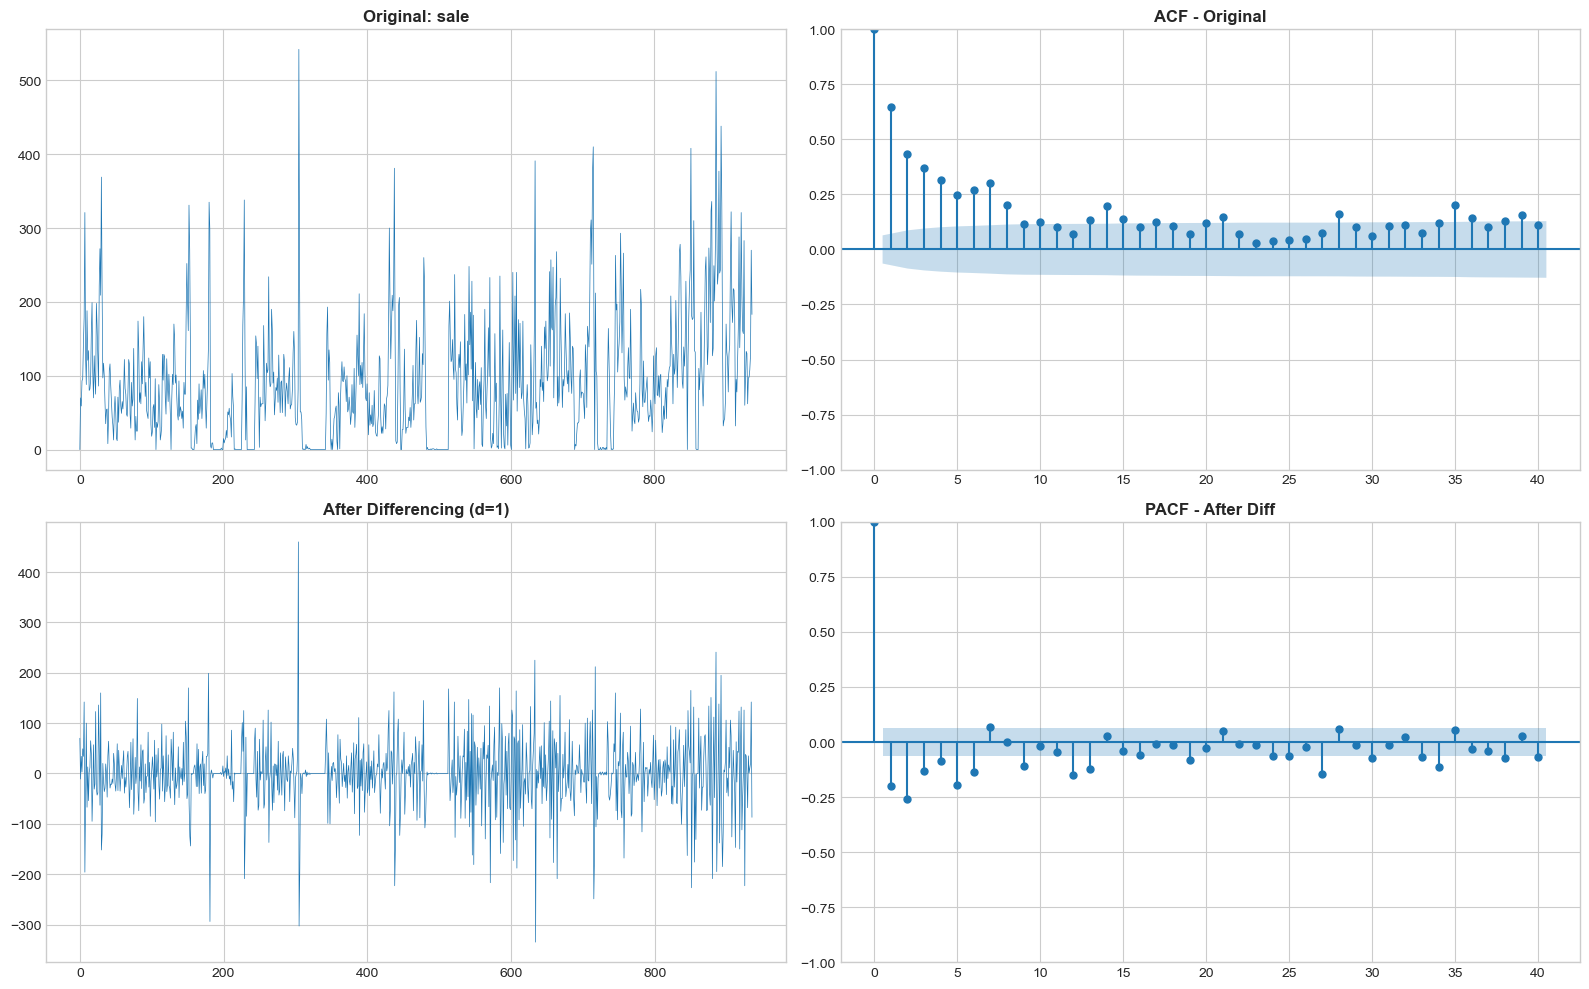

In [10]:
# Tìm cột số để phân tích
numeric_cols = data_retail.select_dtypes(include=[np.number]).columns.tolist()
print(f'Các cột số: {numeric_cols}')

# Chọn cột đầu tiên có giá trị phù hợp
if len(numeric_cols) > 0:
    target_col = numeric_cols[0]
    print(f'\nPhân tích cột: {target_col}')
    
    series = data_retail[target_col].dropna()
    
    # Plot ACF/PACF
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Original
    axes[0, 0].plot(series.values, linewidth=0.5)
    axes[0, 0].set_title(f'Original: {target_col}', fontweight='bold')
    
    plot_acf(series, ax=axes[0, 1], lags=40)
    axes[0, 1].set_title('ACF - Original', fontweight='bold')
    
    # After differencing
    diff_series = series.diff().dropna()
    axes[1, 0].plot(diff_series.values, linewidth=0.5)
    axes[1, 0].set_title(f'After Differencing (d=1)', fontweight='bold')
    
    plot_pacf(diff_series, ax=axes[1, 1], lags=40)
    axes[1, 1].set_title('PACF - After Diff', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

---
## 🏋️ BÀI TẬP THỰC HÀNH
---

### Bài 1: Nhận Diện Process (⭐ Dễ)

Tạo các process sau và vẽ ACF/PACF:
1. AR(1) với φ = 0.9
2. AR(1) với φ = -0.5
3. MA(1) với θ = 0.7
4. MA(2) với θ₁ = 0.5, θ₂ = -0.3

Nhận xét sự khác biệt ACF/PACF giữa các process.

In [ ]:
# TODO: Viết code ở đây

### Bài 2: Phát Hiện Seasonality (⭐⭐ Trung bình)

Tạo dữ liệu có **cả weekly VÀ monthly seasonality**:
```python
y = 10*sin(2π*t/7) + 20*sin(2π*t/30) + noise
```

1. Vẽ ACF với lags=100
2. Xác định các seasonal period từ ACF
3. Nhận xét: Có thể phát hiện multiple seasonality từ ACF không?

In [ ]:
# TODO: Viết code ở đây

### Bài 3: Xác Định ARIMA Parameters (⭐⭐⭐ Nâng cao)

Với file `stores_sales_forecasting.csv`:
1. Đọc và xử lý dữ liệu
2. Kiểm tra stationarity → Xác định d
3. Vẽ ACF/PACF trên data đã stationary
4. Đề xuất p, d, q cho ARIMA model
5. So sánh đề xuất của bạn với `auto_arima` (nếu có pmdarima)

In [ ]:
# TODO: Viết code ở đây

---
# 🧠 PHẦN ÔN TẬP & CỦNG CỐ KIẾN THỨC - CHƯƠNG 4

---

## 1️⃣ Nguyên Lí 80/20: 20% Kiến Thức Cốt Lõi Mang Lại 80% Giá Trị

> **Nếu bạn chỉ nhớ được 3 điều từ chương này, hãy nhớ:**

### 🔑 Kiến thức #1: ACF = Tổng tương quan, PACF = Chỉ tương quan trực tiếp
- **ACF(k):** Y(t) tương quan với Y(t-k) bao nhiêu? (bao gồm cả ảnh hưởng gián tiếp)
- **PACF(k):** Y(t) tương quan **TRỰC TIẾP** với Y(t-k) bao nhiêu? (loại bỏ trung gian)
- **Khác biệt cốt lõi:** ACF(2) bao gồm ảnh hưởng qua lag 1, PACF(2) loại bỏ ảnh hưởng qua lag 1

### 🔑 Kiến thức #2: Quy tắc vàng chọn p, q cho ARIMA
| ACF | PACF | → Model |
|-----|------|---------|
| Giảm dần | **Cắt** sau lag p | → **AR(p)** — dùng p |
| **Cắt** sau lag q | Giảm dần | → **MA(q)** — dùng q |
| Giảm dần | Giảm dần | → **ARMA(p,q)** — dùng cả hai |

### 🔑 Kiến thức #3: Thanh nằm NGOÀI vùng xanh = Significant
```python
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data, lags=40)   # Xem tổng tương quan
plot_pacf(data, lags=40)  # Xem tương quan trực tiếp

# Đếm số thanh NGOÀI vùng xanh trước khi cắt → đó là p hoặc q
```

> **Một câu tóm tắt:** *"PACF cắt ngang → tìm p (AR), ACF cắt ngang → tìm q (MA), cả hai giảm dần → dùng ARMA."*

---

## 2️⃣ Mô Hình Hóa Kiến Thức: Phép Ẩn Dụ "Gia Phả Gia Đình"

### 👨‍👩‍👧‍👦 Câu chuyện: ACF/PACF giống như ẢNH HƯỞNG GIA ĐÌNH

Hãy tưởng tượng một **gia đình 4 thế hệ:**

```
Cụ → Ông → Bố → Con (BẠN)
```

**ACF (Tổng ảnh hưởng):**
- Con giống Bố? → **Rất nhiều** (lag 1) ← ACF cao
- Con giống Ông? → **Khá nhiều** (lag 2) ← ACF vẫn cao (nhưng qua Bố!)
- Con giống Cụ? → **Một chút** (lag 3) ← ACF vẫn có (qua Ông → Bố)
- ACF **giảm dần** qua các thế hệ

**PACF (Chỉ ảnh hưởng trực tiếp):**
- Con giống Bố **trực tiếp**? → **Rất nhiều** (PACF lag 1 cao)
- Con giống Ông **trực tiếp** (bỏ qua Bố)? → **Ít** (PACF lag 2 thấp)
- Con giống Cụ **trực tiếp** (bỏ qua Ông, Bố)? → **Gần 0** (PACF lag 3 ≈ 0)
- PACF **cắt ngang** sau lag 1!

→ **Kết luận:** Gia đình này là **AR(1)** — chỉ thế hệ trước ảnh hưởng trực tiếp!

| Tình huống | ACF | PACF | Giống model |
|---|---|---|---|
| Con chỉ giống Bố | Giảm dần | Cắt sau lag 1 | AR(1) |
| Con giống cả Bố lẫn Ông trực tiếp | Giảm dần | Cắt sau lag 2 | AR(2) |
| "Tin đồn" lan truyền 1 bước | Cắt sau lag 1 | Giảm dần | MA(1) |

### 🎨 Sơ đồ quy trình xác định model:
```
  Vẽ ACF & PACF
        │
  ┌─────┴──────────────────────┐
  │                            │
  ▼                            ▼
ACF giảm dần?              PACF giảm dần?
PACF cắt ngang?            ACF cắt ngang?
  │                            │
  ▼                            ▼
→ AR(p)                    → MA(q)
  p = lag cuối cùng          q = lag cuối cùng
  PACF ngoài vùng xanh      ACF ngoài vùng xanh
  
  Cả hai giảm dần? → ARMA(p,q) → Dùng auto_arima
```

---

## 3️⃣ Liên Tưởng Với Cuộc Sống

### 🏫 Điểm thi liên tiếp
- **ACF:** Điểm thi lần 3 có liên quan điểm thi lần 1 không? → Có (vì kiến thức tích lũy)
- **PACF:** Điểm thi lần 3 liên quan **trực tiếp** lần 1 (bỏ qua lần 2)? → Ít hơn nhiều
- → Kiểu AR: Kết quả hôm nay chủ yếu phụ thuộc **trực tiếp** kết quả gần nhất

### 📢 Tin đồn lan truyền
- Bạn kể cho A → A kể cho B → B kể cho C
- **ACF:** C nghe giống bạn kể? → Có phần giống (lag 3 vẫn có correlation)
- **PACF:** C giống bạn **trực tiếp** (bỏ qua A, B)? → Không, vì C chỉ nghe từ B
- → Kiểu MA: "Sai số" (tin đồn bị biến dạng) lan truyền qua từng bước

### 🌊 Sóng biển
- **ACF cao ở lag 1, 2, 3... giảm dần:** Sóng này kéo theo sóng sau, sóng sau kéo sóng tiếp → Hiệu ứng dây chuyền (AR process)
- **ACF chỉ cao ở lag 1, rồi cắt:** Mỗi viên đá ném xuống tạo sóng, nhưng sóng không lan xa → MA process

### 🎵 Nhạc
- **AR process:** Giai điệu → Nốt tiếp theo phụ thuộc nốt trước (melody có flow)
- **MA process:** Tiếng trống → Mỗi beat là "shock", ảnh hưởng vang lên trong 1-2 nhịp rồi hết

---

## 4️⃣ Teach to Learn — Giảng Lại Để Hiểu Sâu

### 📝 Bài tập 1: Giải thích ACF vs PACF cho bạn cùng lớp
> Dùng ví dụ **ảnh hưởng gia đình 3 thế hệ** (Ông → Bố → Con).
> Giải thích tại sao PACF "công bằng hơn" ACF trong việc đo ảnh hưởng trực tiếp.

In [ ]:
# ✍️ BÀI TẬP 1: Giải thích ACF vs PACF cho bạn cùng lớp
# Dùng ví dụ ảnh hưởng gia đình 3 thế hệ (Ông → Bố → Con)

"""
Viết giải thích ở đây:

ACF đo cái gì? _______________
PACF đo cái gì? _______________

Ví dụ gia đình:
- ACF(2) = Con giống Ông? → _______________
- PACF(2) = Con giống Ông TRỰC TIẾP? → _______________

Tại sao cần PACF khi đã có ACF? _______________
"""

In [ ]:
# ✍️ BÀI TẬP 2: Đọc kết quả ACF/PACF và chọn model
# Phân tích pattern và đề xuất model phù hợp

"""
CHO KẾT QUẢ:
  ACF:  Lag 1=0.85, Lag 2=0.72, Lag 3=0.60, Lag 4=0.48... (giảm dần)
  PACF: Lag 1=0.85, Lag 2=0.15 (trong vùng xanh), Lag 3=0.05...

CÂU HỎI:
1. ACF có giảm dần không? _______________
2. PACF cắt ngang ở lag nào? _______________
3. Đây là pattern AR, MA, hay ARMA? _______________
4. Order (p hoặc q) là bao nhiêu? _______________
5. Model bạn sẽ fit: ARIMA(___,___,___)
"""

In [ ]:
# ✍️ BÀI TẬP 3: Tự vẽ bảng tổng hợp ACF/PACF
# Viết bảng + thêm 2 ví dụ thực tế cho mỗi pattern

"""
BẢNG TỔNG HỢP (tự viết):

| Pattern | ACF trông như thế nào? | PACF trông như thế nào? | Dùng model gì? |
|---------|----------------------|----------------------|----------------|
| AR(p)   | _______________      | _______________      | _____________  |
| MA(q)   | _______________      | _______________      | _____________  |
| ARMA    | _______________      | _______________      | _____________  |

VÍ DỤ THỰC TẾ MỚI (không có trong bài giảng):

AR process trong thực tế:
1. _______________
2. _______________

MA process trong thực tế:
1. _______________
2. _______________

ARMA process trong thực tế:
1. _______________
2. _______________
"""